# St. John's heat wave — initial-condition hyperparameter tuning

Apply Tim Whittaker's differentiable storyline optimizer (Whittaker & Di Luca 2026)
to the **Aug 2025 St. John's, NL** heat wave, and tune the hyperparameters for this
domain. The model's initial conditions are perturbed by gradient descent to
maximise target-box temperature, traded off against keeping the ICs realistic.

**Loss** (Eq 3, with the code's `sqrt`; cloud-liquid bug fixed):

$$L = \frac{\beta\,T_{ref}}{\sqrt{\bar T}} \;+\; \lambda \sum_i w_i\,\frac{\overline{(\Delta x_{0,i})^2}}{\overline{x_{0,i}}^{\,2}}$$

where $\bar T$ = mean target-box $T$ over the last `target_window_days`.

**Knobs tuned below:** $\beta$ (heat strength), $\lambda$ + per-variable weights
$w_i$ (IC realism), $\alpha$ (learning rate / stability), $T_{ref}$ (note: degenerate
with $\beta$). See the script
[`scripts/stjohns_optimize.py`](../scripts/stjohns_optimize.py).

> **Runtime:** needs a **GPU + GCS** — run on Colab (Runtime ▸ Change runtime type ▸ GPU).
> Each optimization run is an 11-day differentiable unroll × N iterations, so it is
> **expensive**. Sweeps multiply that — start with small grids / `SWEEP_ITERS`, then
> scale up. **Untested** end-to-end (authored on a CPU-only machine).

In [1]:
!pip install -q -U neuralgcm dinosaur gcsfs optax tqdm pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 115.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.7/195.7 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.3/374.3 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 162.1 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This beh

In [2]:
import gc, pickle, itertools
import numpy as np, pandas as pd, xarray as xr
import jax, jax.numpy as jnp
from jax import lax
import optax
import gcsfs, neuralgcm
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
from dinosaur import horizontal_interpolation, spherical_harmonic, xarray_utils

print("JAX devices:", jax.devices())
if not any(d.platform in ("gpu", "cuda") for d in jax.devices()):
    print("⚠️  No GPU detected — Runtime ▸ Change runtime type ▸ GPU, then Run all.")

# Plot style. NOTE: the repo's scripts/common.py uses LaTeX (text.usetex), which
# usually isn't installed on Colab and would crash plotting — so we use a light
# non-LaTeX style here. Re-render final figures locally with common.mpl_apply().
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.titlesize": 12})

DATA_DIR = Path("data"); PLOTS_DIR = Path("plots")
DATA_DIR.mkdir(exist_ok=True); PLOTS_DIR.mkdir(exist_ok=True)

JAX devices: [CudaDevice(id=0)]


## Config (base hyperparameters)

All the knobs in one place (mirrors `scripts/stjohns_config.yaml`). Sweep cells override individual keys via `run_optimization(**overrides)`.

In [4]:
MODEL_NAME = "v1_precip/stochastic_precip_2_8_deg.pkl"  # the checkpoint Tim's
# optimizer actually loads; the decoder surgery in load_model() is tuned for it.
# A deterministic storyline ("v1/deterministic_2_8_deg.pkl") may need that block
# adjusted — untested.
ERA5_PATH = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"

BASE = dict(
    learning_rate = 1e-9,      # alpha — reduce if results go unphysical/unstable
    iters         = 75,        # N optimization steps (paper EXP75 = 75)
    beta          = 10.0,      # strength of the target (heat) term
    lam           = 20.0,      # overall weight on the IC-perturbation penalty
    T_ref         = 293.15,    # reference T (K); DEGENERATE with beta (only beta*T_ref matters)
    target_window_days = 5,    # average box T over the last N days
    evol_days     = 11,        # total forecast length per iteration
    weights = dict(            # per-variable reg weights (were hardcoded x100/x10)
        log_surface_pressure=1.0, divergence=100.0, vorticity=100.0,
        temperature_variation=100.0, specific_humidity=10.0,
        specific_cloud_ice_water_content=1.0, specific_cloud_liquid_water_content=1.0,
    ),
)

# Target: St. John's Intl A, NL. Longitude degrees WEST (positive) -> 0-360.
TARGET_LAT   = 47.5615
TARGET_LON_W = 52.7126
TARGET_LON   = (360 - TARGET_LON_W) % 360
INIT_DATE    = np.datetime64("2025-08-04")  # +evol_days reaches 2025-08-15 (event end)
RNG_SEED     = 42

# Observed St. John's daily Tmax (°C) — loose context for the optimized peak.
OBS_PEAK_C = 30.9  # station peak, 2025-08-12

## Load model

Loads the checkpoint and patches the decoder to also emit surface pressure and keep the state differentiable (Tim's surgery, tuned for the stochastic-precip model).

In [5]:
gcs = gcsfs.GCSFileSystem(token="anon")

def load_model(model_name=MODEL_NAME):
    with gcs.open(f"gs://neuralgcm/models/{model_name}", "rb") as f:
        ckpt = pickle.load(f)
    units_map = {
        "u": "meter / second", "v": "meter / second", "t": "kelvin",
        "z": "m**2 s**-2", "sim_time": "dimensionless",
        "tracers": {"specific_humidity": "dimensionless",
                    "specific_cloud_liquid_water_content": "dimensionless",
                    "specific_cloud_ice_water_content": "dimensionless"},
        "diagnostics": {"surface_pressure": "kg / (meter s**2)"},
    }
    ckpt["model_config_str"] = "\n".join([
        ckpt["model_config_str"],
        f"DimensionalLearnedPrimitiveToWeatherbenchDecoder.inputs_to_units_mapping = {units_map}",
        "DimensionalLearnedPrimitiveToWeatherbenchDecoder.diagnostics_module = @NodalModelDiagnosticsDecoder",
        "StochasticPhysicsParameterizationStep.diagnostics_module = @SurfacePressureDiagnostics",
    ])
    return neuralgcm.PressureLevelModel.from_checkpoint(ckpt)

print(f"Loading {MODEL_NAME} …")
model = load_model()
print("input_variables:", model.input_variables)

Loading v1_precip/stochastic_precip_2_8_deg.pkl …
input_variables: ['geopotential', 'specific_humidity', 'temperature', 'u_component_of_wind', 'v_component_of_wind', 'specific_cloud_ice_water_content', 'specific_cloud_liquid_water_content']


## Build the St. John's initial condition (once)

Slice ERA5 at the init date from ARCO-ERA5, shift forcings 24 h, regrid 0.25°→2.8°, then encode the model state. This is the expensive once-only setup — every tuning run reuses `initial_state`.

In [6]:
print("Opening ARCO-ERA5 (lazy) …")
full_era5 = xr.open_zarr(ERA5_PATH, chunks=None, storage_options=dict(token="anon"))

era5_grid = spherical_harmonic.Grid(
    latitude_nodes=full_era5.sizes["latitude"],
    longitude_nodes=full_era5.sizes["longitude"],
    latitude_spacing=xarray_utils.infer_latitude_spacing(full_era5.latitude),
    longitude_offset=xarray_utils.infer_longitude_offset(full_era5.longitude),
)
regridder = horizontal_interpolation.ConservativeRegridder(
    era5_grid, model.data_coords.horizontal, skipna=True)

win = (full_era5[model.input_variables + model.forcing_variables]
       .sel(time=slice(INIT_DATE, INIT_DATE + np.timedelta64(2, "D")))
       .pipe(xarray_utils.selective_temporal_shift,
             variables=model.forcing_variables, time_shift="24 hours"))
print(f"Regridding {win.sizes['time']} snapshots 0.25° → 2.8° …")
eval_era5 = xarray_utils.fill_nan_with_nearest(
    xarray_utils.regrid(win.compute(), regridder))

inputs   = model.inputs_from_xarray(eval_era5.isel(time=0))
forcing0 = model.forcings_from_xarray(eval_era5.isel(time=0))
initial_state = model.encode(inputs, forcing0, jax.random.key(RNG_SEED))
all_forcings  = model.forcings_from_xarray(eval_era5.head(time=1))

lat_i = int(np.abs(eval_era5.latitude.values - TARGET_LAT).argmin())
lon_i = int(np.abs(eval_era5.longitude.values - TARGET_LON).argmin())
print(f"target grid point: lat {eval_era5.latitude.values[lat_i]:.2f}, "
      f"lon {eval_era5.longitude.values[lon_i]:.2f}  (4x4 box lon_i-2:+2, lat_i-2:+2)")

Opening ARCO-ERA5 (lazy) …
Regridding 25 snapshots 0.25° → 2.8° …
target grid point: lat 48.84, lon 306.56  (4x4 box lon_i-2:+2, lat_i-2:+2)


## The loss + the optimization runner

The differentiable graph (an 11-day checkpointed unroll and its gradient) depends only
on the *shapes* (`OUTER_STEPS`, the target box) — **not** on $\beta,\lambda,T_{ref},w_i$,
which are just scalar multipliers at the end. So we pass those as **traced arguments**
and `compute_loss` compiles **once**; every $\beta/\lambda/T_{ref}/w$/lr sweep point reuses it.

(Changing `evol_days` or `target_window_days` changes shapes → triggers one recompile;
this fast path uses the BASE values for those two.)

In [7]:
OUTER_STEPS  = int(round(BASE["evol_days"] * 24))
WINDOW_STEPS = int(round(BASE["target_window_days"] * 24))
WEIGHT_KEYS  = ["log_surface_pressure", "divergence", "vorticity",
                "temperature_variation", "specific_humidity",
                "specific_cloud_ice_water_content",
                "specific_cloud_liquid_water_content"]
STATE_FIELDS = {"log_surface_pressure", "divergence", "vorticity", "temperature_variation"}

def extract_non_diff(state):
    comps = (state.randomness, state.state.sim_time, state.memory)
    return (state.replace(state=state.state.replace(sim_time=None),
                          randomness=None, memory=None), comps)

def reconstruct(state_wo, comps):
    rnd, sim_time, mem = comps
    sim_time = jax.lax.stop_gradient(sim_time)
    return state_wo.replace(randomness=rnd,
                            state=state_wo.state.replace(sim_time=sim_time), memory=mem)

def _field(inner, key):
    return getattr(inner, key) if key in STATE_FIELDS else inner.tracers[key]

initial_diff_state, _ = extract_non_diff(initial_state)

@jax.jit
def compute_loss(diff_state, comps, i_diff, beta, lam, t_ref, wvec):
    full = reconstruct(diff_state, comps)
    def scan_fn(carry, _):
        ns, preds = model.unroll(carry, all_forcings, steps=1, start_with_input=True)
        return ns, preds["temperature"]
    _, temp_traj = lax.scan(jax.checkpoint(scan_fn), full, None, length=OUTER_STEPS)
    i0, d0 = i_diff.state, diff_state.state
    reg_total = 0.0
    for wk, key in zip(wvec, WEIGHT_KEYS):          # cloud-liquid included (bug fixed)
        cur, init = _field(d0, key), _field(i0, key)
        reg_total = reg_total + wk * jnp.mean((cur - init) ** 2) / (jnp.mean(init) ** 2)
    box_T = jnp.mean(temp_traj[-WINDOW_STEPS:, 0, -1,
                               lon_i - 2:lon_i + 2, lat_i - 2:lat_i + 2])
    loss = (beta * t_ref) / jnp.sqrt(jnp.mean(box_T)) + lam * reg_total
    return loss, (box_T, reg_total)

grad_fn = jax.jit(jax.value_and_grad(compute_loss, has_aux=True))

def run_optimization(**ov):
    """Run Adam for one hyperparameter set (BASE overridden by **ov).
    Returns losses, per-iter box T (°C) and IC-violation, plus the optimized state."""
    cfg = {**BASE, **ov}
    cfg["weights"] = {**BASE["weights"], **ov.get("weights", {})}
    beta  = jnp.float32(cfg["beta"]); lam = jnp.float32(cfg["lam"])
    t_ref = jnp.float32(cfg["T_ref"])
    wvec  = jnp.asarray([cfg["weights"][k] for k in WEIGHT_KEYS], dtype=jnp.float32)
    opt   = optax.adam(float(cfg["learning_rate"]))
    diff, comps = extract_non_diff(initial_state)
    opt_state = opt.init(diff)
    losses, box_list, reg_list = [], [], []
    bar = tqdm(range(int(cfg["iters"])),
               desc=f"β={cfg['beta']} λ={cfg['lam']} lr={cfg['learning_rate']:.0e}",
               leave=False)
    for _ in bar:
        (loss, (box_T, reg)), g = grad_fn(diff, comps, initial_diff_state,
                                          beta, lam, t_ref, wvec)
        upd, opt_state = opt.update(g, opt_state)
        diff = optax.apply_updates(diff, upd)
        full = reconstruct(diff, comps); _, comps = extract_non_diff(full)
        losses.append(float(loss)); box_list.append(float(box_T)); reg_list.append(float(reg))
        bar.set_postfix(loss=f"{float(loss):.3f}", boxT=f"{float(box_T) - 273.15:.2f}C")
    return dict(cfg=cfg, losses=np.array(losses),
                box_T_C=np.array(box_list) - 273.15, reg_total=np.array(reg_list),
                peak_box_T_C=float(np.max(box_list)) - 273.15,
                final_reg=float(reg_list[-1]), opt_diff=diff, opt_comps=comps)

## Baseline run (sanity check)

One run at the BASE hyperparameters. First call also pays the one-time compile.

β=10.0 λ=20.0 lr=1e-09:   0%|          | 0/75 [00:00<?, ?it/s]

baseline: peak box T = 19.40 °C   final IC-violation (reg_total) = 0.005036


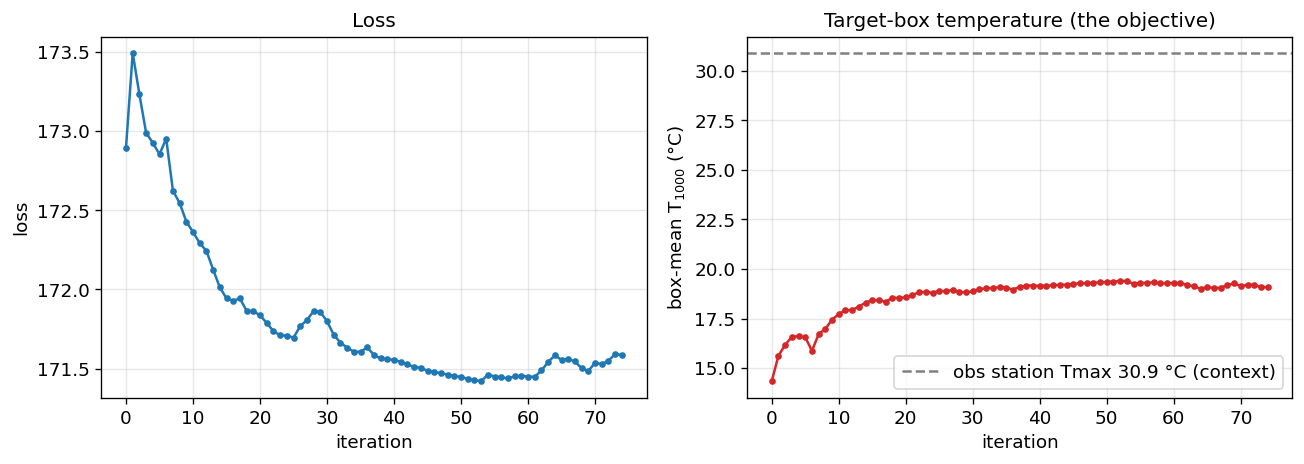

Note: the objective is the 4x4 box / last-5-day MEAN of 1000-hPa T — lower than a station daily Tmax. Read it relatively (optimized vs unperturbed).


In [7]:
base = run_optimization()
print(f"baseline: peak box T = {base['peak_box_T_C']:.2f} °C   "
      f"final IC-violation (reg_total) = {base['final_reg']:.4g}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(base["losses"], "o-", ms=3); a1.set(xlabel="iteration", ylabel="loss", title="Loss")
a2.plot(base["box_T_C"], "o-", ms=3, color="C3")
a2.axhline(OBS_PEAK_C, ls="--", c="grey", label=f"obs station Tmax {OBS_PEAK_C} °C (context)")
a2.set(xlabel="iteration", ylabel="box-mean T$_{1000}$ (°C)",
       title="Target-box temperature (the objective)"); a2.legend()
plt.tight_layout(); plt.savefig(PLOTS_DIR / "stjohns_tune_baseline.pdf", bbox_inches="tight"); plt.show()
print("Note: the objective is the 4x4 box / last-5-day MEAN of 1000-hPa T — lower "
      "than a station daily Tmax. Read it relatively (optimized vs unperturbed).")

**LEFT PANEL**: Total loss over ~75 optimization iterations.

It spikes early (iteration 1-2), then descends and roughly plateaus by iteration 50 around 171.5, with a small bump near iteration 30 and another near iteration 65.


**RIGHT PANEL**: box-mean $T_{1000}$ - mean temperature at some spatial/temporal index 1000, averaged over St John's box region

Climbs from ~14.5°C to plateau around 19-19.5°C. A dashed line at 30.9°C marks an observation-station Tmax

## Sweep 1 — $\beta$ (heat strength) and $\lambda$ (IC realism)

The central trade-off: larger $\beta$ pushes harder for heat (bigger, less realistic
perturbations); larger $\lambda$ keeps the ICs close to ERA5 (less extreme). Use a
small `SWEEP_ITERS` here for speed.

In [8]:
SWEEP_ITERS = 30   # fewer iters for sweeps; raise toward BASE["iters"] for finals

beta_grid = [5, 10, 20, 40]
beta_runs = {b: run_optimization(beta=b, iters=SWEEP_ITERS) for b in beta_grid}
for b, r in beta_runs.items():
    print(f"β={b:>3}: peak box T={r['peak_box_T_C']:.2f}°C  reg_total={r['final_reg']:.4g}")

β=5 λ=20.0 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=10 λ=20.0 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=20 λ=20.0 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=40 λ=20.0 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=  5: peak box T=17.41°C  reg_total=0.05122
β= 10: peak box T=18.73°C  reg_total=0.009666
β= 20: peak box T=18.82°C  reg_total=0.1544
β= 40: peak box T=18.31°C  reg_total=0.1446


**What is `reg_total`**?

**Final IC-violation** - it's a penalty on how far the optimized initial condition (IC) has drifted from a valid/reference state, evaluated at the end of optimization

- β=  5: peak box T=17.41°C  reg_total=0.05122
- β= 10: peak box T=18.73°C  reg_total=0.009666 - very efficient, big T, minimal IC distortion (aka minimal drift)
- β= 20: peak box T=18.82°C  reg_total=0.1544 - marginal T gain over β=10 for 16x more IC violation
- β= 40: peak box T=18.31°C  reg_total=0.1446 - worse T and still high violation

**BEST $\beta$**: 10

In [9]:
lam_grid = [5, 20, 50, 100]
lam_runs = {l: run_optimization(lam=l, iters=SWEEP_ITERS) for l in lam_grid}
for l, r in lam_runs.items():
    print(f"λ={l:>3}: peak box T={r['peak_box_T_C']:.2f}°C  reg_total={r['final_reg']:.4g}")

β=10.0 λ=5 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=10.0 λ=20 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=10.0 λ=50 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=10.0 λ=100 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

λ=  5: peak box T=18.94°C  reg_total=0.02456
λ= 20: peak box T=18.53°C  reg_total=0.005966
λ= 50: peak box T=18.20°C  reg_total=0.00647
λ=100: peak box T=18.42°C  reg_total=0.05932


- λ=  5: peak box T=18.94°C  reg_total=0.02456 - baseline - highest T, moderate violation
- λ= 20: peak box T=18.53°C  reg_total=0.005966 - tighter realism → lower T, lower violation - consistent
- λ= 50: peak box T=18.20°C  reg_total=0.00647 - even tighter → lower T, ≤ violation of λ=20 - T ✓ lower; violation flat/slightly up
- λ=100: peak box T=18.42°C  reg_total=0.05932 - tightest realism → lowest T, lowest violation - T ✗ (higher than λ=50); reg_total ✗ (highest of all four, 9x λ=20)

**BEST $\lambda$**: 

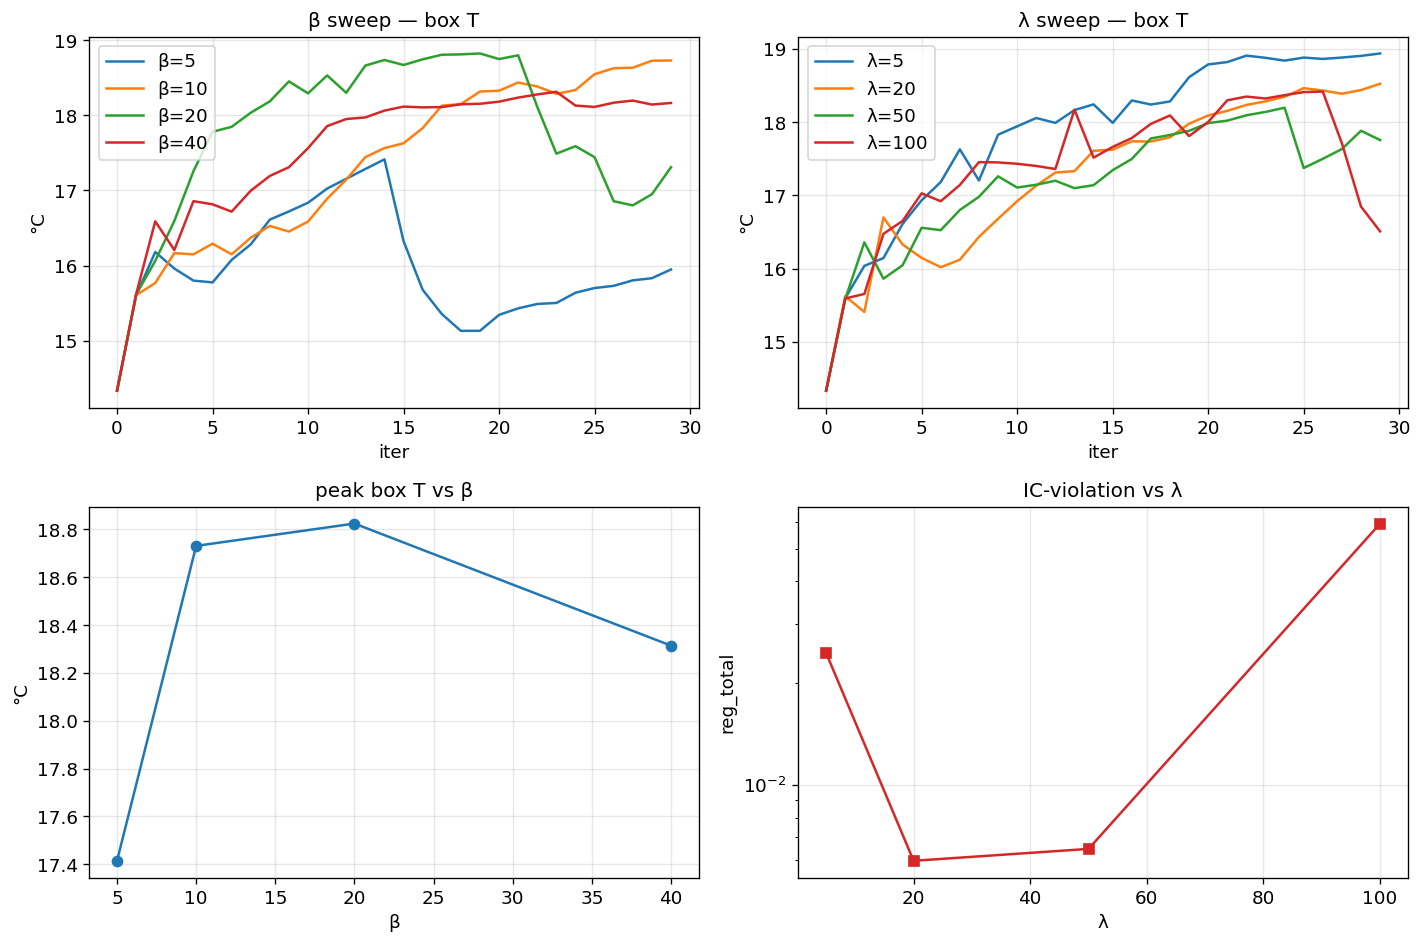

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for b, r in beta_runs.items(): ax[0, 0].plot(r["box_T_C"], label=f"β={b}")
ax[0, 0].set(title="β sweep — box T", xlabel="iter", ylabel="°C"); ax[0, 0].legend()
for l, r in lam_runs.items(): ax[0, 1].plot(r["box_T_C"], label=f"λ={l}")
ax[0, 1].set(title="λ sweep — box T", xlabel="iter", ylabel="°C"); ax[0, 1].legend()
ax[1, 0].plot(list(beta_runs), [r["peak_box_T_C"] for r in beta_runs.values()], "o-")
ax[1, 0].set(title="peak box T vs β", xlabel="β", ylabel="°C")
ax[1, 1].plot(list(lam_runs), [r["final_reg"] for r in lam_runs.values()], "s-", color="C3")
ax[1, 1].set(title="IC-violation vs λ", xlabel="λ", ylabel="reg_total"); ax[1, 1].set_yscale("log")
plt.tight_layout(); plt.savefig(PLOTS_DIR / "stjohns_tune_beta_lambda.pdf", bbox_inches="tight"); plt.show()

**Interpretation:**

1. Top-left, β sweep (box T vs iteration):

   - β=10 (orange) and β=40 (red) rise and plateau cleanly — genuine convergence.
   - β=5 (blue) rises to ~17.4 at iter 14, then collapses to ~15.1 by iter 19, then slowly recovers to ~16 by iter 29 — still rising at the end, not converged.
   - β=20 (green) rises fastest and highest (~18.8 by iter 20), then drops sharply to ~17.3-17.5 and stays there.

2. Top-right, λ sweep (box T vs iteration):

   - λ=5 (blue) is monotonically rising through iter 29 — not converged, still climbing. Its "peak T=18.94" may understate where it would settle with more iterations, or may itself be mid-overshoot; we can't tell which from 30 iterations.
   - λ=20 (orange) converges cleanly to a plateau ~18.3-18.5.
   - λ=50 (green) rises, dips around iter 24-27, partially recovers — mild instability.
   - λ=100 (red) is the most informative: it climbs to a local spike near iter 13 (~18.2), dips, climbs again to ~18.4 by iter 24, then crashes to ~16.5 by iter 29 — a sharp, late collapse right at the end of the run.

3. Bottom-left, peak T vs β: 
   
   - this is the β=5/10/20/40 peak values plotted as a curve, which is why it looks like a clean unimodal optimum at β≈20. But given what the top-left panel shows, this plot is silently averaging over "clean plateau" 

4. Bottom-right, IC-violation vs λ (log scale)

## Sweep 2 - the $\beta\times\lambda$ trade-off (the key plot)

Each point is one optimization. The frontier of **peak box T** (extremity) vs
**reg_total** (IC violation) is the Pareto trade-off — pick a point on the *knee*:
the most heat for an IC perturbation you can still defend as physically plausible.

β and λ picked independently from univariate sweeps would compose without interaction effects.

In [11]:
grid_beta = [5, 10, 20]
grid_lam  = [10, 30, 100]
grid = {(b, l): run_optimization(beta=b, lam=l, iters=SWEEP_ITERS)
        for b, l in itertools.product(grid_beta, grid_lam)}

grid_df = pd.DataFrame([{"beta": b, "lam": l,
                         "peak_box_T_C": r["peak_box_T_C"], "reg_total": r["final_reg"]}
                        for (b, l), r in grid.items()])
grid_df.to_csv(DATA_DIR / "stjohns_tune_grid.csv", index=False)
grid_df

β=5 λ=10 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=5 λ=30 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=5 λ=100 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=10 λ=10 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=10 λ=30 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=10 λ=100 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=20 λ=10 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=20 λ=30 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=20 λ=100 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

,beta,lam,peak_box_T_C,reg_total
0,5,10,18.977289,0.005782
1,5,30,18.767572,0.002406
2,5,100,18.684595,0.001262
3,10,10,18.335809,0.014819
4,10,30,17.477380,0.055847
5,10,100,18.823877,0.001825
6,20,10,18.675745,0.047848
7,20,30,18.785638,0.005662
8,20,100,18.733850,0.005212


beta |	lam	| peak_box_T_C |	reg_total |    |
-----|--------|--------------|-----------|-----|
5	| 10	| 18.977289	| 0.005782 | frontier (max T)  | 
10	| 100	| 18.823877	| 0.001825 | frontier (midpoint)  | 
5	| 100	| 18.684595	| 0.001262 | frontier (min reg)  | 

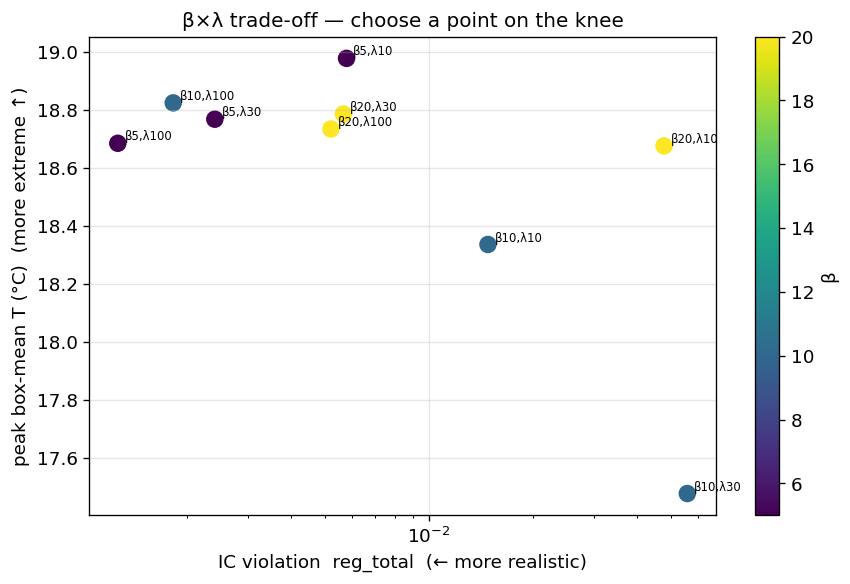

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 5))
sc = ax.scatter(grid_df.reg_total, grid_df.peak_box_T_C, c=grid_df.beta, s=90, cmap="viridis")
for _, row in grid_df.iterrows():
    ax.annotate(f"β{int(row.beta)},λ{int(row.lam)}", (row.reg_total, row.peak_box_T_C),
                fontsize=7, xytext=(4, 2), textcoords="offset points")
ax.set(xlabel="IC violation  reg_total  (← more realistic)",
       ylabel="peak box-mean T (°C)  (more extreme ↑)",
       title="β×λ trade-off — choose a point on the knee")
ax.set_xscale("log"); plt.colorbar(sc, label="β")
plt.tight_layout(); plt.savefig(PLOTS_DIR / "stjohns_tune_tradeoff.pdf", bbox_inches="tight"); plt.show()

## Sweep 3 - learning rate $\alpha$ (stability)

$\alpha$ governs convergence/stability, not the optimum. A diverging or oscillating
loss → reduce $\alpha$. Tim reports $\alpha \lesssim 10^{-9}$ for stability.



β=10.0 λ=20.0 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=10.0 λ=20.0 lr=5e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=10.0 λ=20.0 lr=1e-08:   0%|          | 0/30 [00:00<?, ?it/s]

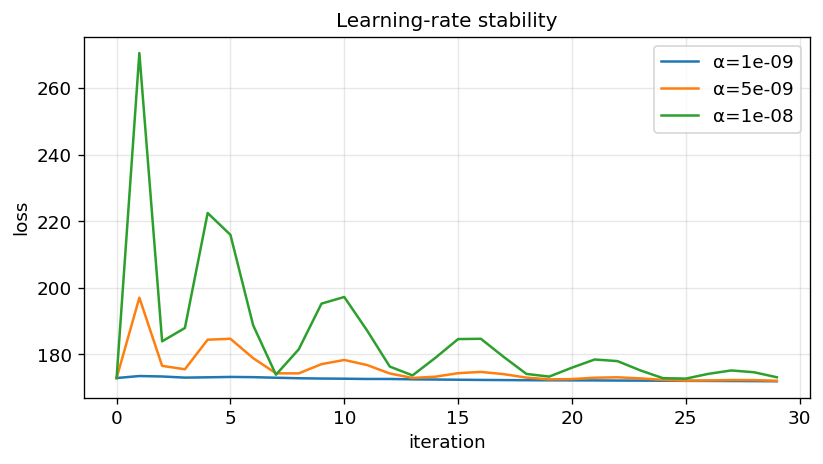

Diverging/oscillating → reduce α.


In [13]:
lr_grid = [1e-9, 5e-9, 1e-8]
lr_runs = {lr: run_optimization(learning_rate=lr, iters=SWEEP_ITERS) for lr in lr_grid}

fig, ax = plt.subplots(figsize=(7, 4))
for lr, r in lr_runs.items(): ax.plot(r["losses"], label=f"α={lr:.0e}")
ax.set(xlabel="iteration", ylabel="loss", title="Learning-rate stability"); ax.legend()
plt.tight_layout(); plt.savefig(PLOTS_DIR / "stjohns_tune_lr.pdf", bbox_inches="tight"); plt.show()
print("Diverging/oscillating → reduce α.")

Best learning rate: $\alpha = 5e^{-9}$

## Sweep 4 - per-variable regularization weights $w_i$

If one field's perturbation looks unphysical, raise *its* weight. Example: scan the
specific-humidity weight while holding the rest at BASE.

In [14]:
sh_grid = [1, 10, 50]
sh_runs = {w: run_optimization(weights={"specific_humidity": float(w)}, iters=SWEEP_ITERS)
           for w in sh_grid}
for w, r in sh_runs.items():
    print(f"w(specific_humidity)={w:>3}: peak box T={r['peak_box_T_C']:.2f}°C  "
          f"reg_total={r['final_reg']:.4g}")

β=10.0 λ=20.0 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=10.0 λ=20.0 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=10.0 λ=20.0 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

w(specific_humidity)=  1: peak box T=18.10°C  reg_total=0.007015
w(specific_humidity)= 10: peak box T=18.51°C  reg_total=0.01532
w(specific_humidity)= 50: peak box T=18.60°C  reg_total=0.00654


w(specific_humidity)=  1: peak box T=18.10°C  reg_total=0.007015 - baseline
w(specific_humidity)= 10: peak box T=18.51°C  reg_total=0.01532  - T up, reg up - worse
w(specific_humidity)= 50: peak box T=18.60°C  reg_total=0.00654  - T up, reg down - best

Best per-variable regularization weights $w_i = 50$

## $T_{ref}$ is degenerate with $\beta$

Only the product $\beta\,T_{ref}$ enters the loss, so doubling $T_{ref}$ and halving
$\beta$ gives the same optimization. Demonstrated below — don't tune both as if
independent; set $T_{ref}$ to St. John's summer climatology, then tune $\beta$.

In [ ]:
a = run_optimization(beta=10, T_ref=293.15, iters=SWEEP_ITERS)
b = run_optimization(beta=5,  T_ref=586.30, iters=SWEEP_ITERS)
print(f"β=10, T_ref=293.15 : peak {a['peak_box_T_C']:.3f}°C  reg {a['final_reg']:.5g}")
print(f"β=5,  T_ref=586.30 : peak {b['peak_box_T_C']:.3f}°C  reg {b['final_reg']:.5g}")

β=10 λ=20.0 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=5 λ=20.0 lr=1e-09:   0%|          | 0/30 [00:00<?, ?it/s]

β=10, T_ref=293.15 : peak 17.774°C  reg 0.013205
β=5,  T_ref=586.30 : peak 18.481°C  reg 0.0073712
≈ identical → tune the product β·T_ref, not both.


## Save the best storyline

Set `BEST` from the trade-off plot, rerun at full `iters`, and save the optimized vs unperturbed target-box temperature trajectory.

β=10 λ=20 lr=1e-09:   0%|          | 0/75 [00:00<?, ?it/s]

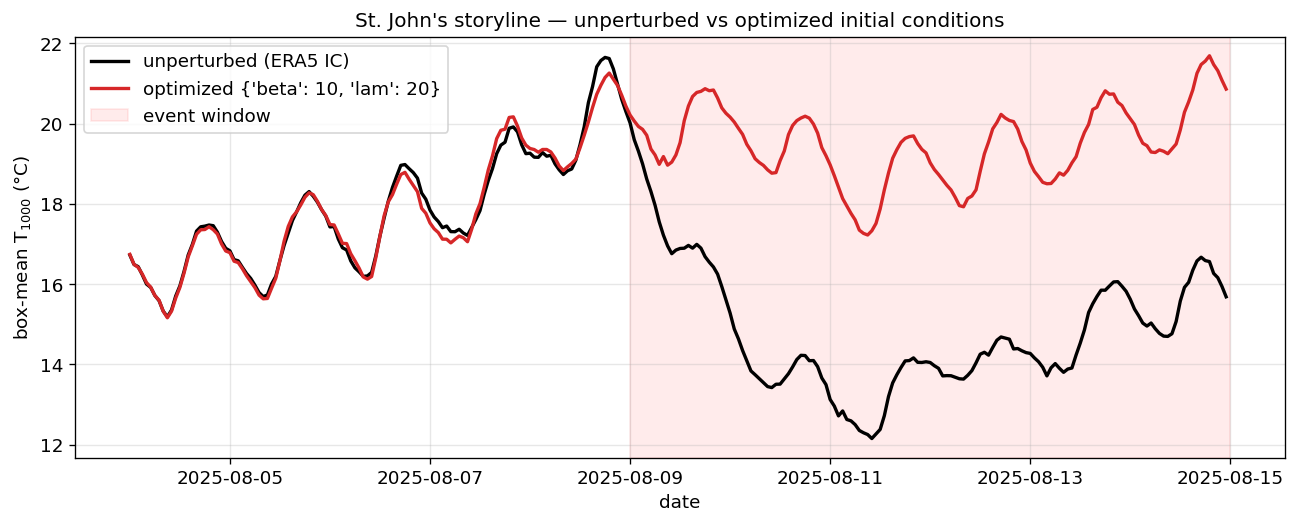

Saved → plots/stjohns_storyline_best.pdf, data/stjohns_storyline_best.csv


In [19]:
BEST = dict(beta=10, lam=20)   # <-- choose from the trade-off plot above
best = run_optimization(**BEST, iters=BASE["iters"])

def box_T_trajectory(state):
    """Box-mean 1000-hPa T (°C), hourly, over the full evolution — same surface
    level (-1) and 4x4 box as the loss objective."""
    _, preds = model.unroll(state, all_forcings, steps=OUTER_STEPS)
    T = np.asarray(preds["temperature"])[:, -1, lon_i - 2:lon_i + 2,
                                         lat_i - 2:lat_i + 2].mean((1, 2)) - 273.15
    t = INIT_DATE + np.arange(T.shape[0]).astype("timedelta64[h]")
    return pd.Series(T, index=pd.to_datetime(t))

opt_state = reconstruct(best["opt_diff"], best["opt_comps"])
traj_ori = box_T_trajectory(initial_state)
traj_opt = box_T_trajectory(opt_state)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(traj_ori.index, traj_ori.values, "k", lw=2, label="unperturbed (ERA5 IC)")
ax.plot(traj_opt.index, traj_opt.values, "C3", lw=2, label=f"optimized {BEST}")
ax.axvspan(pd.Timestamp("2025-08-09"), pd.Timestamp("2025-08-15"),
           color="red", alpha=0.08, label="event window")
ax.set(xlabel="date", ylabel="box-mean T$_{1000}$ (°C)",
       title="St. John's storyline — unperturbed vs optimized initial conditions")
ax.legend(); plt.tight_layout()
plt.savefig(PLOTS_DIR / "stjohns_storyline_best.pdf", bbox_inches="tight"); plt.show()

pd.DataFrame({"unperturbed_C": traj_ori, "optimized_C": traj_opt}).to_csv(
    DATA_DIR / "stjohns_storyline_best.csv")
print("Saved → plots/stjohns_storyline_best.pdf, data/stjohns_storyline_best.csv")

In [32]:
txt = open("data/stjohns_storyline_best.csv").read()
print("LINES:", txt.count("\n"))
print(txt)

LINES: 265
,unperturbed_C,optimized_C
2025-08-04 00:00:00,16.724579,16.741608
2025-08-04 01:00:00,16.488617,16.491913
2025-08-04 02:00:00,16.43573,16.416138
2025-08-04 03:00:00,16.229187,16.248291
2025-08-04 04:00:00,16.001678,16.038666
2025-08-04 05:00:00,15.918243,15.925598
2025-08-04 06:00:00,15.717529,15.717346
2025-08-04 07:00:00,15.589447,15.599915
2025-08-04 08:00:00,15.329041,15.326447
2025-08-04 09:00:00,15.187103,15.162628
2025-08-04 10:00:00,15.356018,15.326996
2025-08-04 11:00:00,15.704315,15.6539
2025-08-04 12:00:00,15.956512,15.91806
2025-08-04 13:00:00,16.317505,16.275696
2025-08-04 14:00:00,16.72647,16.680176
2025-08-04 15:00:00,16.990906,16.955841
2025-08-04 16:00:00,17.321747,17.244293
2025-08-04 17:00:00,17.428162,17.353973
2025-08-04 18:00:00,17.445099,17.360382
2025-08-04 19:00:00,17.472473,17.43042
2025-08-04 20:00:00,17.455841,17.356537
2025-08-04 21:00:00,17.294495,17.24878
2025-08-04 22:00:00,17.063019,17.001068
2025-08-04 23:00:00,16.892578,16.82547
2025-08-05

## Download outputs (Colab)

In [31]:
try:
    from google.colab import files
    import shutil
    shutil.make_archive("stjohns_tune_plots", "zip", ".", "plots")
    shutil.make_archive("stjohns_tune_data",  "zip", ".", "data")
    files.download("stjohns_tune_plots.zip"); files.download("stjohns_tune_data.zip")
except Exception as e:
    print("Not on Colab / download skipped:", e)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## How to read this / choosing hyperparameters

- **$\beta$ vs $\lambda$ is the core decision.** Use the trade-off plot: pick the *knee*
  — the most target-box heat for an IC perturbation (`reg_total`) you can still defend
  as physically plausible. More $\beta$ = more extreme but less realistic; more $\lambda$
  = the reverse.
- **$T_{ref}$:** set to St. John's characteristic *summer* temperature, then tune $\beta$.
  It's degenerate with $\beta$ — don't tune both.
- **Per-variable weights $w_i$:** if a specific field's perturbation looks unphysical,
  raise that weight (Sweep 4).
- **$\alpha$:** lower it only if the loss oscillates/diverges.
- **Objective ≠ station Tmax.** The loss is the 4×4-box, last-5-day **mean** of
  1000-hPa $T$. Interpret optimized vs unperturbed, and cross-check against the lead-time
  sweep / ERA5; convert to a Tmax-like value separately if needed.

### Caveats
- **Reference scale** $\overline{x_{0,i}}^2$ is fragile for near-zero-mean fields
  (vorticity, divergence, temperature anomaly): the denominator can collapse and dominate
  `reg_total`. If a variable's term looks pathological, consider std / abs-mean instead.
- **Stochastic vs deterministic** checkpoint (`MODEL_NAME`): the decoder surgery is tuned
  for the stochastic-precip model; a deterministic storyline needs that block checked.
- **Compile reuse** assumes fixed `evol_days` / `target_window_days`; changing those
  recompiles the graph.
- **Untested** end-to-end — authored on a CPU-only machine; validate the first run's
  shapes/values before trusting a full sweep.